In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 130,
    'savefig.bbox'    : 'tight',
    'savefig.dpi'     : 150,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

ORANGE = '#FF9900'   # Amazon orange
DARK   = '#232F3E'   # Amazon dark navy
BLUE   = '#146EB4'   # Amazon blue
PALETTE = [ORANGE, DARK, BLUE, '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12', '#1ABC9C']

print("✅ Imports ready")

✅ Imports ready


In [2]:
BASE_DIR = r"C:\Users\pooja\OneDrive\Desktop\Amazon_Sales_Analytics"
EXPORTS_DIR = os.path.join(BASE_DIR, "exports")
PLOTS_DIR   = os.path.join(BASE_DIR, "screenshots", "eda")
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_plot(filename):
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f"  💾 Saved → {filename}")

print(f"✅ Plots will save to: {PLOTS_DIR}")

✅ Plots will save to: C:\Users\pooja\OneDrive\Desktop\Amazon_Sales_Analytics\screenshots\eda


In [3]:
data_path = os.path.join(EXPORTS_DIR, "amazon_transactions_clean.csv")
df = pd.read_csv(data_path, low_memory=False, parse_dates=['order_date'])

# Convenience columns
df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['month_name']    = df['order_date'].dt.strftime('%b')
df['order_quarter'] = df['order_date'].dt.quarter

print(f"✅ Loaded: {len(df):,} rows × {df.shape[1]} columns")
print(f"   Years : {sorted(df['order_year'].unique())}")
print(f"   Date  : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
df.head(3)

✅ Loaded: 1,127,609 rows × 46 columns
   Years : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
   Date  : 2015-01-01 → 2025-12-31


,transaction_id,order_date,customer_id,product_id,product_name_x,category_x,subcategory_x,brand_x,original_price_inr,discount_percent,...,category_y,subcategory_y,brand_y,base_price_2015,weight_kg,rating,is_prime_eligible_y,launch_year,model,month_name
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,Electronics,Smartphones,Samsung,123614.29,27.91,...,electronics,Smartphones,samsung,123614.29,0.19,4.7,True,2015,Galaxy S6,Jan
1,TXN_2015_00000002,2015-01-05,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,electronics,Smartphones,oneplus,54731.86,0.20,4.1,True,2015,OnePlus 2,Jan
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,Electronics,Smartphones,Samsung,97644.25,46.93,...,electronics,Smartphones,samsung,97644.25,0.17,3.3,True,2015,Galaxy Note 5,Jan


  💾 Saved → 01_yearly_revenue.png


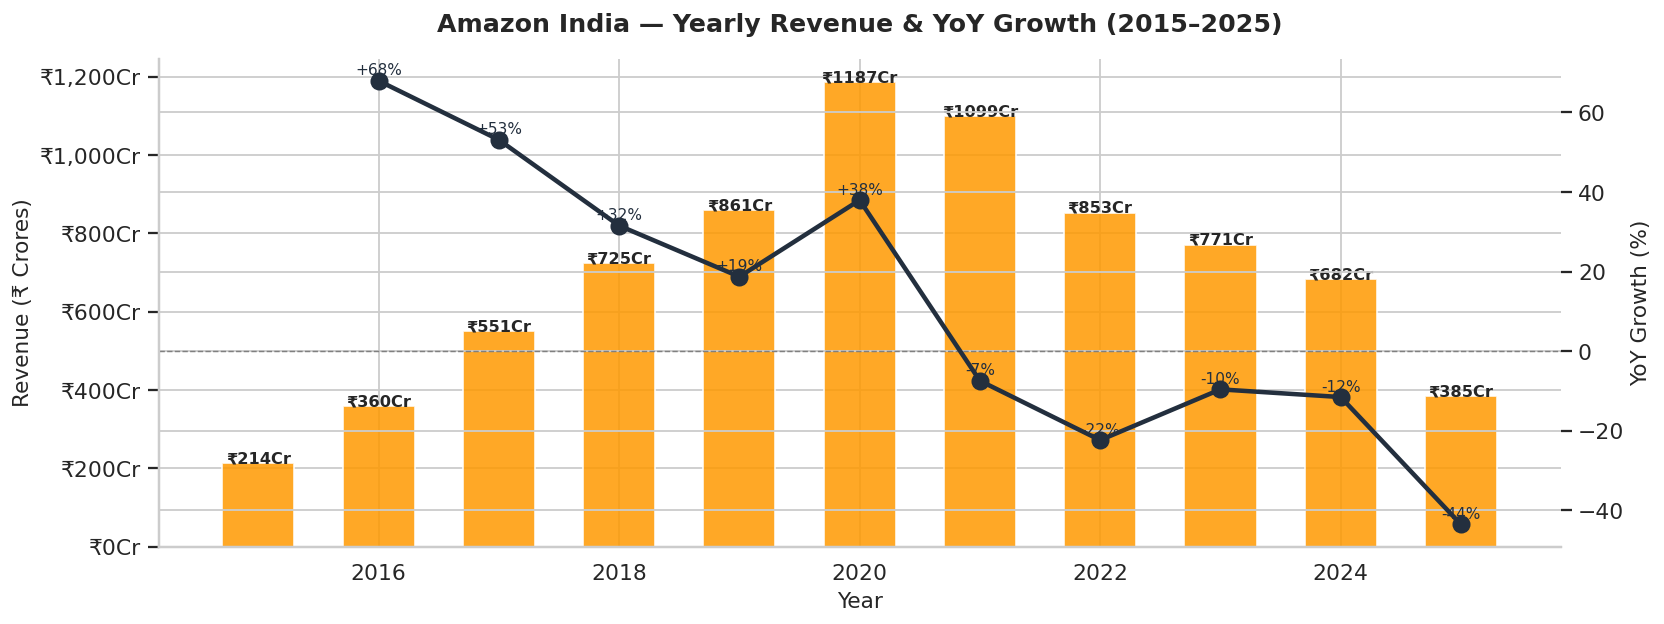


💡 INSIGHT:
   Highest growth year : 2016 at +68.0%
   Total revenue range : ₹214Cr → ₹1187Cr


In [4]:
yearly = (df.groupby('order_year')['final_amount_inr']
            .sum()
            .reset_index())
yearly['revenue_cr']  = yearly['final_amount_inr'] / 1e7   # Convert to Crores
yearly['growth_pct']  = yearly['revenue_cr'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')

# Bars = revenue
bars = ax1.bar(yearly['order_year'], yearly['revenue_cr'],
               color=ORANGE, alpha=0.85, width=0.6, zorder=2)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Revenue (₹ Crores)', fontsize=12)
ax1.set_title('Amazon India — Yearly Revenue & YoY Growth (2015–2025)',
              fontsize=14, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}Cr'))

# Line = growth %
ax2 = ax1.twinx()
ax2.plot(yearly['order_year'], yearly['growth_pct'],
         'o-', color=DARK, linewidth=2.5, markersize=9, zorder=3)
ax2.set_ylabel('YoY Growth (%)', fontsize=12)
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.8)

# Labels on bars
for _, row in yearly.iterrows():
    ax1.text(row['order_year'], row['revenue_cr'] + 0.5,
             f'₹{row["revenue_cr"]:.0f}Cr',
             ha='center', fontsize=9, fontweight='bold')
    if not pd.isna(row['growth_pct']):
        ax2.text(row['order_year'], row['growth_pct'] + 1.5,
                 f"{row['growth_pct']:+.0f}%",
                 ha='center', fontsize=8.5, color=DARK)

fig.tight_layout()
save_plot('01_yearly_revenue.png')
plt.show()

# ── Business Insight ──────────────────────────────────────────
print("\n💡 INSIGHT:")
peak_yr = yearly.loc[yearly['growth_pct'].idxmax()]
print(f"   Highest growth year : {int(peak_yr['order_year'])} at {peak_yr['growth_pct']:+.1f}%")
print(f"   Total revenue range : ₹{yearly['revenue_cr'].min():.0f}Cr → ₹{yearly['revenue_cr'].max():.0f}Cr")

  💾 Saved → 02_monthly_heatmap.png


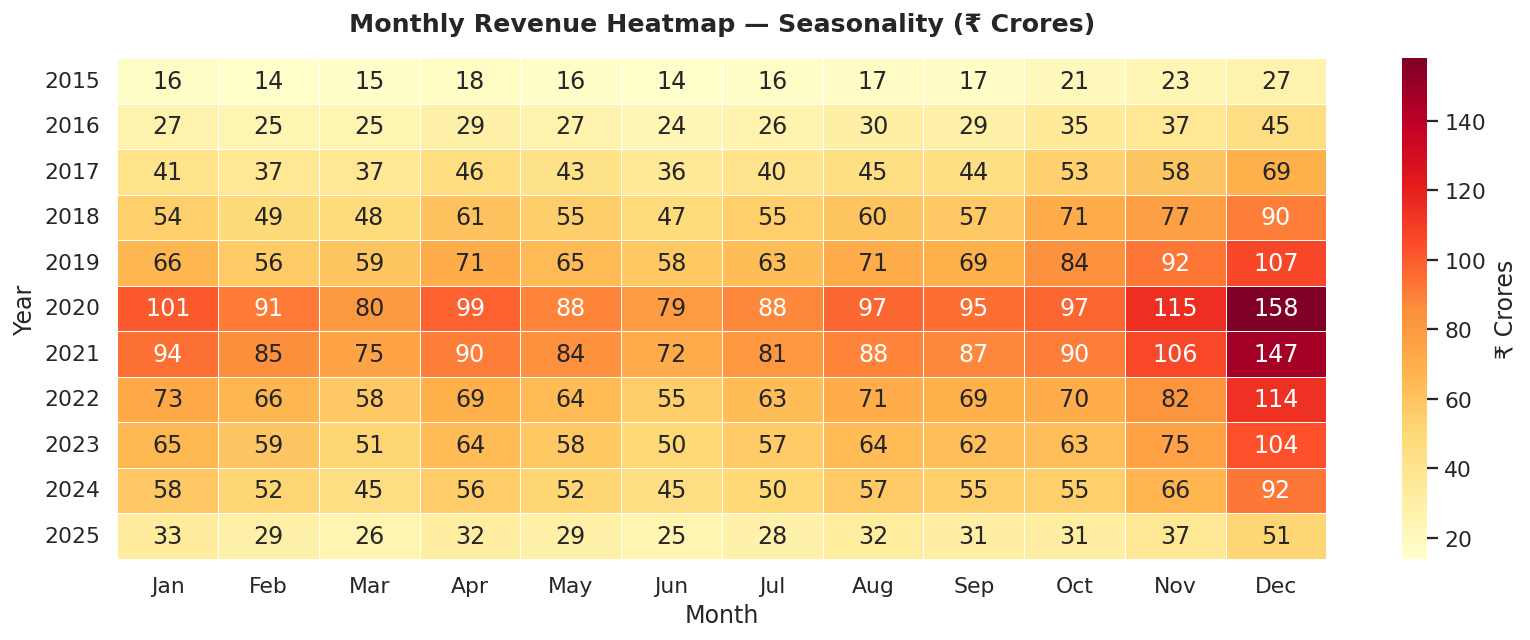


💡 INSIGHT:
   Top 3 months by avg revenue: ['Dec', 'Nov', 'Oct']
   Peak month avg: ₹91Cr vs lowest: ₹46Cr


In [5]:
pivot = (df.groupby(['order_year', 'order_month'])['final_amount_inr']
           .sum()
           .unstack(fill_value=0) / 1e7)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [month_names[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': '₹ Crores'})
ax.set_title('Monthly Revenue Heatmap — Seasonality (₹ Crores)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Year')
save_plot('02_monthly_heatmap.png')
plt.show()

# ── Business Insight ──────────────────────────────────────────
monthly_avg = pivot.mean()
top3 = monthly_avg.nlargest(3)
print("\n💡 INSIGHT:")
print(f"   Top 3 months by avg revenue: {list(top3.index)}")
print(f"   Peak month avg: ₹{top3.iloc[0]:.0f}Cr vs lowest: ₹{monthly_avg.nsmallest(1).iloc[0]:.0f}Cr")

In [7]:
print(df.columns)

Index(['transaction_id', 'order_date', 'customer_id', 'product_id',
       'product_name_x', 'category_x', 'subcategory_x', 'brand_x',
       'original_price_inr', 'discount_percent', 'discounted_price_inr',
       'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr',
       'customer_city', 'customer_state', 'customer_tier',
       'customer_spending_tier', 'customer_age_group', 'payment_method',
       'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale',
       'festival_name', 'customer_rating', 'return_status', 'order_month',
       'order_year', 'order_quarter', 'product_weight_kg',
       'is_prime_eligible_x', 'product_rating', 'source_year',
       'product_name_y', 'category_y', 'subcategory_y', 'brand_y',
       'base_price_2015', 'weight_kg', 'rating', 'is_prime_eligible_y',
       'launch_year', 'model', 'month_name'],
      dtype='str')


  💾 Saved → 03_category_performance.png


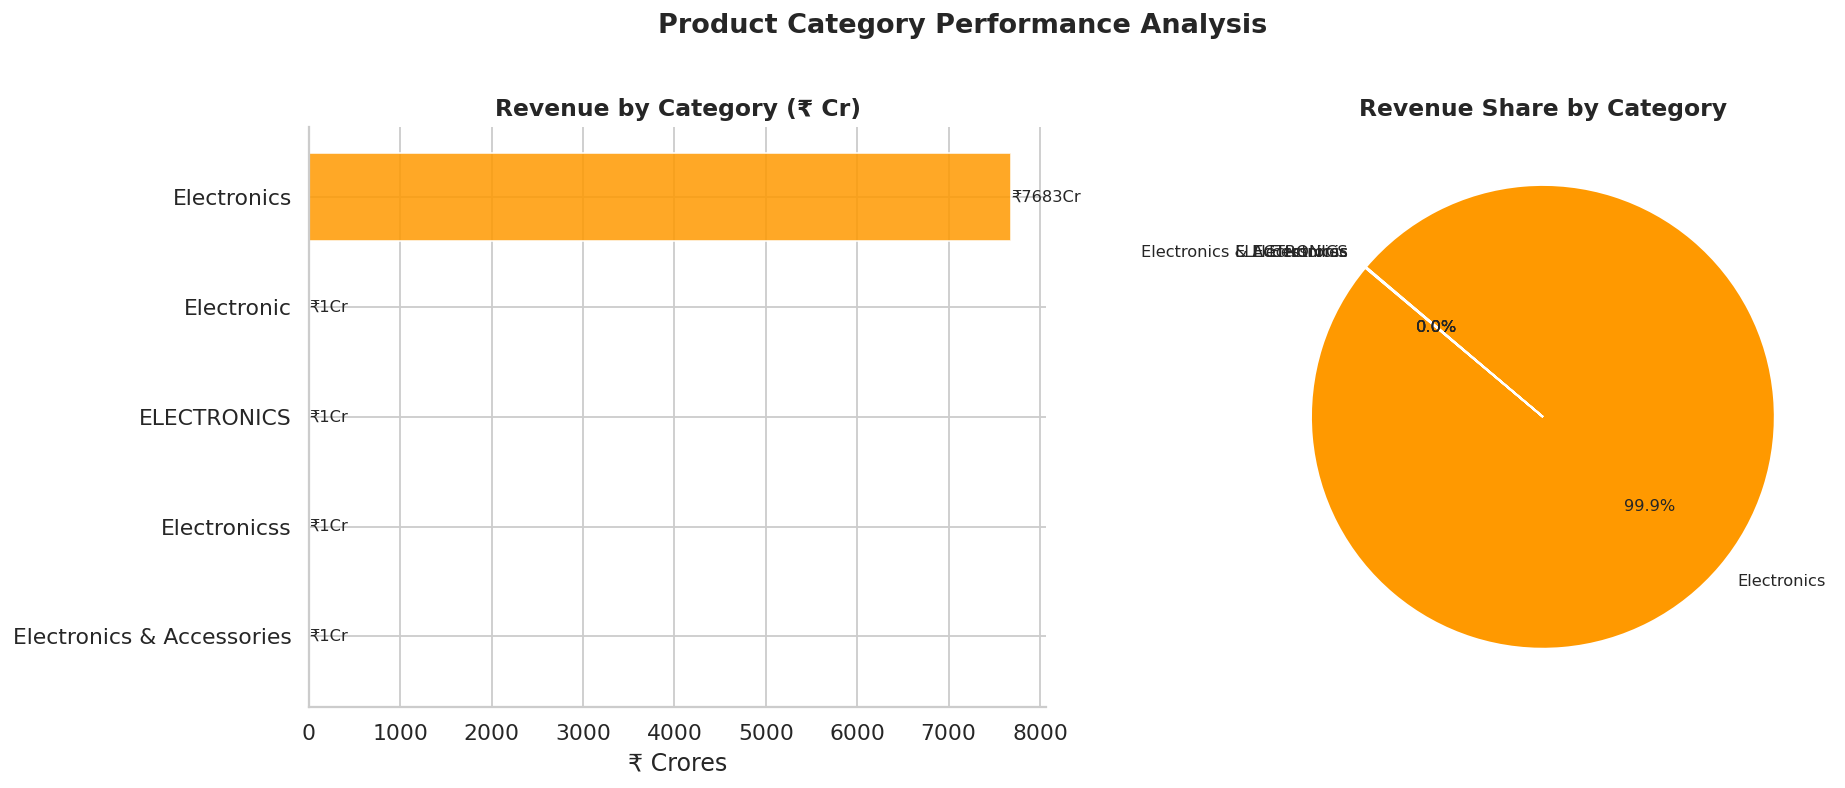


💡 INSIGHT:
   Top category : Electronics — ₹7683Cr
   Avg order val: ₹68,190


In [9]:
cat = (df.groupby('category_x')
         .agg(revenue=('final_amount_inr','sum'),
              orders=('transaction_id','count'),
              avg_value=('final_amount_inr','mean'))
         .reset_index()
         .sort_values('revenue', ascending=False))
cat['rev_cr'] = cat['revenue'] / 1e7

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Revenue bar
colors = PALETTE[:len(cat)]
bars = axes[0].barh(cat['category_x'], cat['rev_cr'],
                    color=colors, alpha=0.85)
axes[0].set_title('Revenue by Category (₹ Cr)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('₹ Crores')
axes[0].invert_yaxis()
for bar, val in zip(bars, cat['rev_cr']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'₹{val:.0f}Cr', va='center', fontsize=9)

# Right: Pie chart
axes[1].pie(cat['revenue'], labels=cat['category_x'],
            autopct='%1.1f%%', colors=colors,
            startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Revenue Share by Category',
                  fontsize=13, fontweight='bold')

fig.suptitle('Product Category Performance Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_plot('03_category_performance.png')
plt.show()

print("\n💡 INSIGHT:")
top_cat = cat.iloc[0]
print(f"   Top category : {top_cat['category_x']} — ₹{top_cat['rev_cr']:.0f}Cr")
print(f"   Avg order val: ₹{top_cat['avg_value']:,.0f}")

  💾 Saved → 04_payment_evolution.png


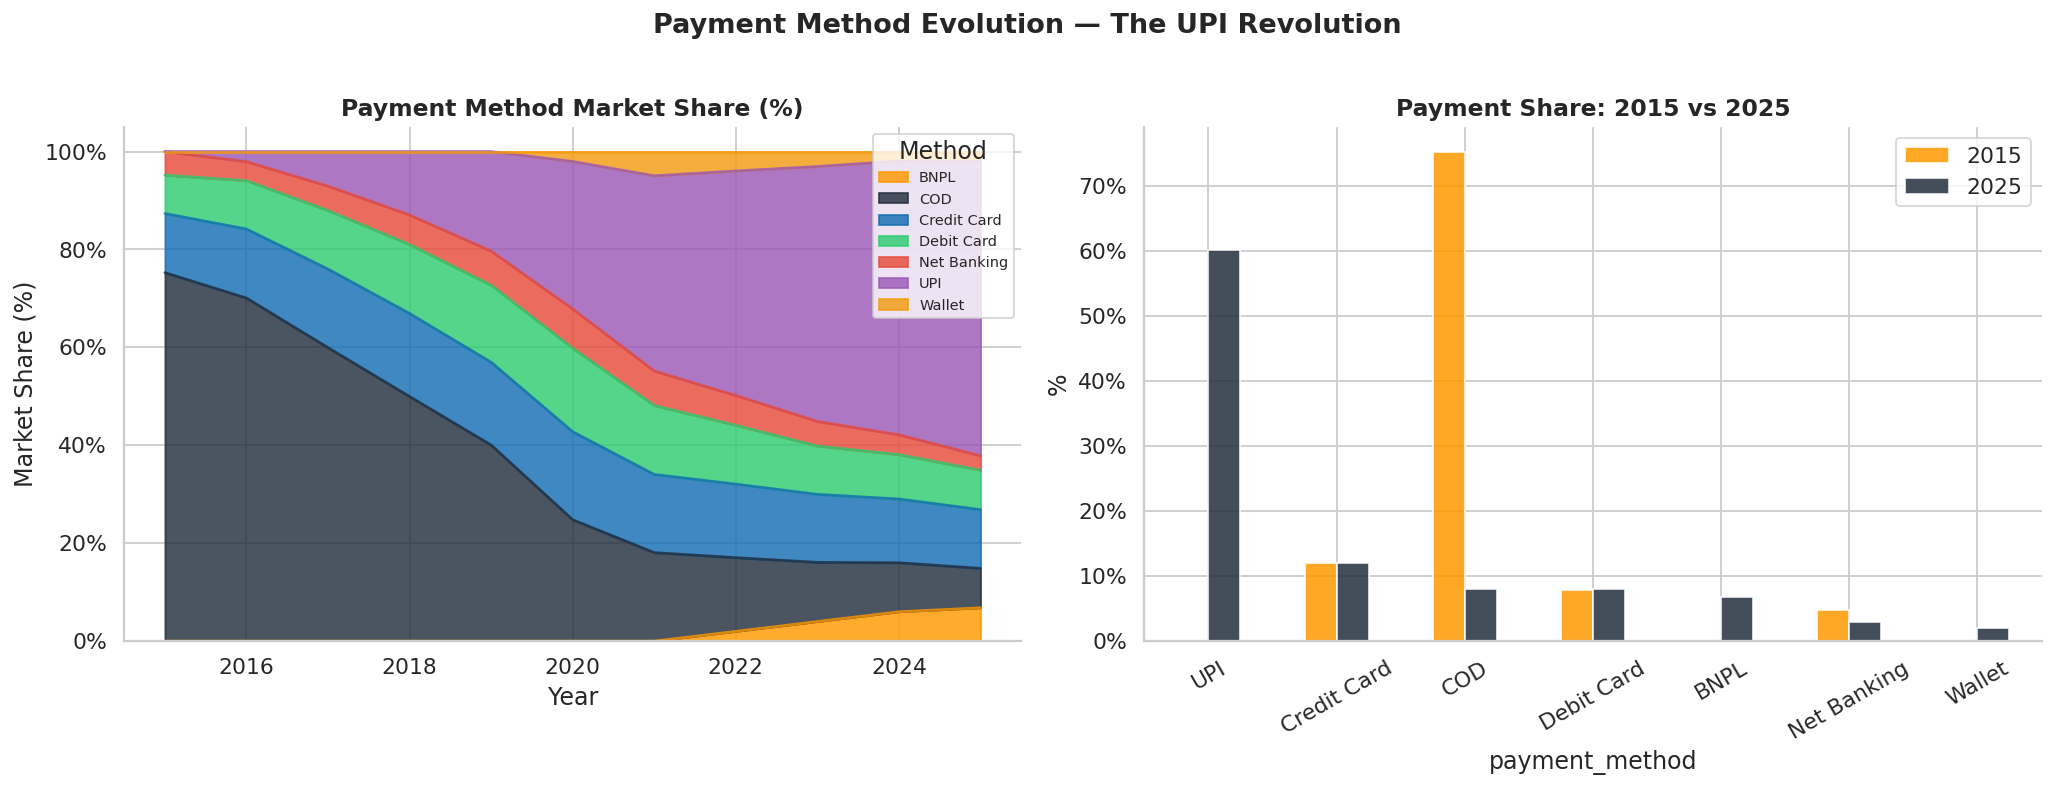


💡 INSIGHT:
   UPI share: 0.0% (2015) → 60.1% (2025)
   COD share: 75.3% (2015) → 8.1% (2025)


In [11]:
pay_yr = (df.groupby(['order_year','payment_method'])['transaction_id']
            .count()
            .unstack(fill_value=0))
pay_pct = pay_yr.div(pay_yr.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Stacked area — market share over time
pay_pct.plot(kind='area', stacked=True, ax=axes[0],
             alpha=0.82, color=PALETTE[:len(pay_pct.columns)])
axes[0].set_title('Payment Method Market Share (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Market Share (%)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(title='Method', loc='upper right', fontsize=8)

# Right: Grouped bar for first vs last year
first_yr = pay_yr.index.min()
last_yr  = pay_yr.index.max()
compare  = pd.DataFrame({
    str(first_yr): pay_pct.loc[first_yr],
    str(last_yr) : pay_pct.loc[last_yr]
}).sort_values(str(last_yr), ascending=False).head(7)
compare.plot(kind='bar', ax=axes[1], color=[ORANGE, DARK], alpha=0.85)
axes[1].set_title(f'Payment Share: {first_yr} vs {last_yr}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

fig.suptitle('Payment Method Evolution — The UPI Revolution',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_plot('04_payment_evolution.png')
plt.show()

print("\n💡 INSIGHT:")
if 'UPI' in pay_pct.columns:
    upi_start = pay_pct['UPI'].iloc[0]
    upi_end   = pay_pct['UPI'].iloc[-1]
    print(f"   UPI share: {upi_start:.1f}% ({first_yr}) → {upi_end:.1f}% ({last_yr})")
if 'COD' in pay_pct.columns:
    cod_start = pay_pct['COD'].iloc[0]
    cod_end   = pay_pct['COD'].iloc[-1]
    print(f"   COD share: {cod_start:.1f}% ({first_yr}) → {cod_end:.1f}% ({last_yr})")

  💾 Saved → 05_prime_comparison.png


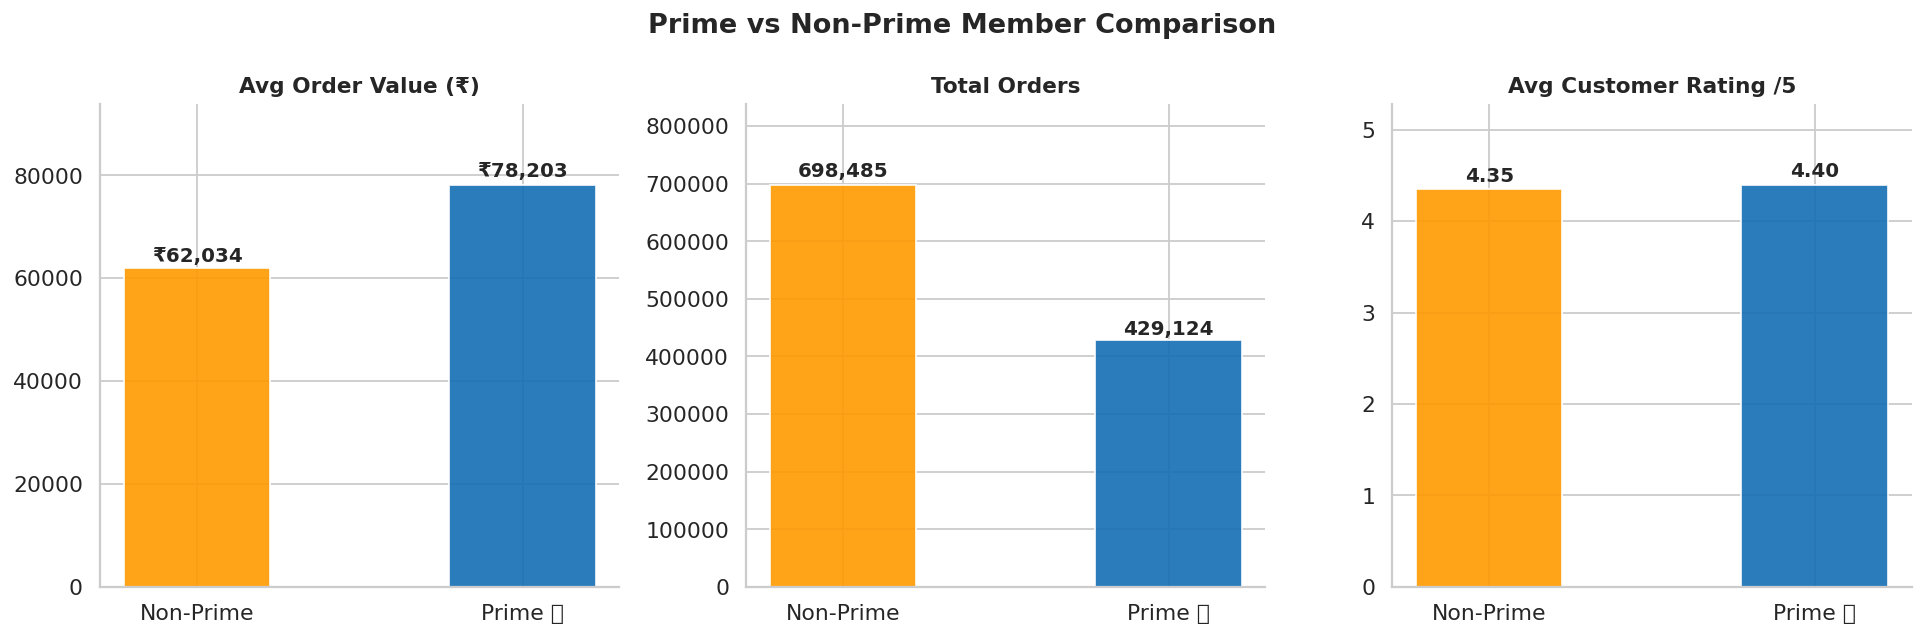


💡 INSIGHT:
   Prime avg order value  : ₹78,203
   Non-Prime avg order val: ₹62,034
   Prime premium          : +26.1%


In [12]:
prime = (df.groupby('is_prime_member')
           .agg(orders=('transaction_id','count'),
                avg_value=('final_amount_inr','mean'),
                total_rev=('final_amount_inr','sum'),
                avg_rating=('customer_rating','mean'))
           .reset_index())
prime['label']  = prime['is_prime_member'].map({1:'Prime ⭐', 0:'Non-Prime'})
prime['rev_cr'] = prime['total_rev'] / 1e7

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ('avg_value',  'Avg Order Value (₹)',     '₹{:,.0f}'),
    ('orders',     'Total Orders',             '{:,}'),
    ('avg_rating', 'Avg Customer Rating /5',  '{:.2f}'),
]
for ax, (col, title, fmt) in zip(axes, metrics):
    bars = ax.bar(prime['label'], prime[col],
                  color=[ORANGE, BLUE], width=0.45, alpha=0.9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                fmt.format(bar.get_height()),
                ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, prime[col].max() * 1.2)

fig.suptitle('Prime vs Non-Prime Member Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('05_prime_comparison.png')
plt.show()

print("\n💡 INSIGHT:")
p  = prime[prime['label'].str.startswith('Prime')]['avg_value'].values[0]
np_val = prime[prime['label'].str.startswith('Non')]['avg_value'].values[0]
print(f"   Prime avg order value  : ₹{p:,.0f}")
print(f"   Non-Prime avg order val: ₹{np_val:,.0f}")
print(f"   Prime premium          : +{((p/np_val)-1)*100:.1f}%")

  💾 Saved → 06_geographic_revenue.png


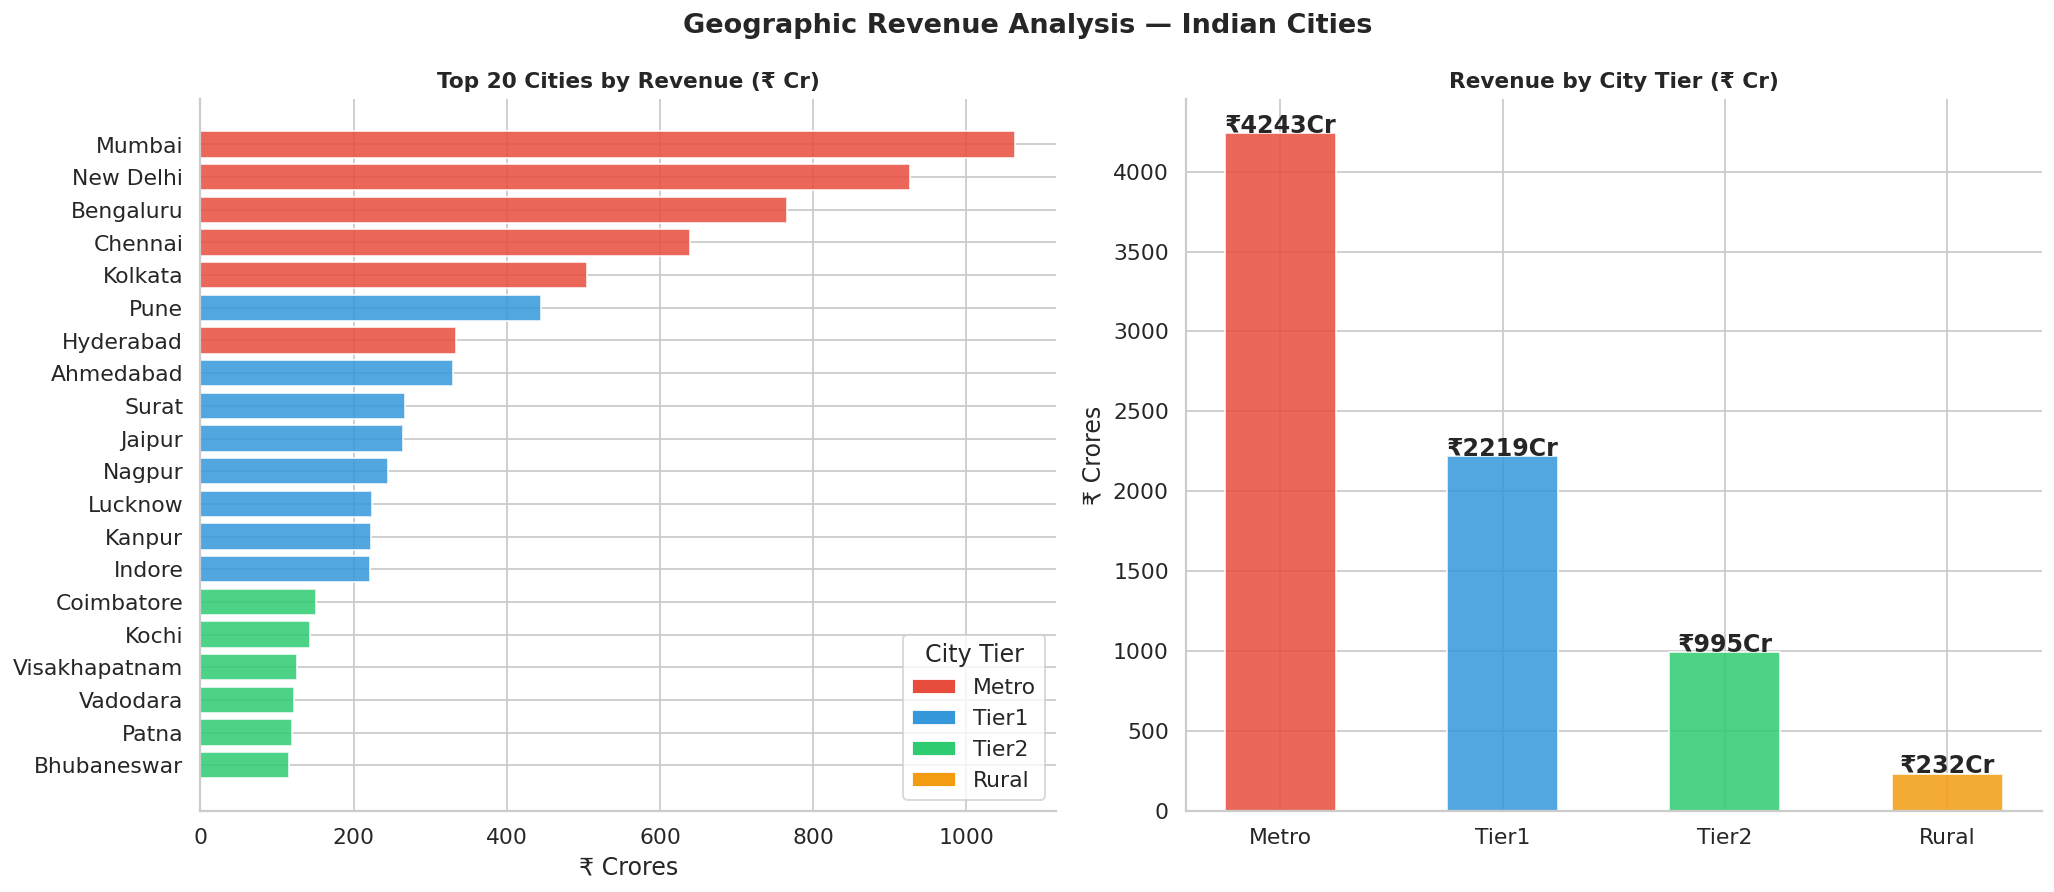


💡 INSIGHT:
   Metro cities contribute: 55.2% of total revenue
   Top city: Mumbai — ₹1064Cr


In [13]:
city_rev = (df.groupby(['customer_city','customer_tier'])['final_amount_inr']
              .sum()
              .reset_index()
              .sort_values('final_amount_inr', ascending=False))
city_rev['rev_cr'] = city_rev['final_amount_inr'] / 1e7
top20 = city_rev.head(20)

tier_rev = (df.groupby('customer_tier')['final_amount_inr']
              .sum()
              .sort_values(ascending=False) / 1e7)

TIER_COLORS = {'Metro':'#E74C3C', 'Tier1':'#3498DB',
               'Tier2':'#2ECC71', 'Rural':'#F39C12'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Top 20 cities
bar_colors = [TIER_COLORS.get(t, ORANGE) for t in top20['customer_tier']]
axes[0].barh(top20['customer_city'], top20['rev_cr'],
             color=bar_colors, alpha=0.85)
axes[0].set_title('Top 20 Cities by Revenue (₹ Cr)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('₹ Crores')
axes[0].invert_yaxis()

from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=t) for t, c in TIER_COLORS.items()]
axes[0].legend(handles=legend, title='City Tier', loc='lower right')

# Right: Revenue by tier
tier_bars = axes[1].bar(tier_rev.index, tier_rev.values,
                        color=[TIER_COLORS.get(t, ORANGE) for t in tier_rev.index],
                        alpha=0.85, width=0.5)
axes[1].set_title('Revenue by City Tier (₹ Cr)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('₹ Crores')
for bar, val in zip(tier_bars, tier_rev):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.5, f'₹{val:.0f}Cr',
                 ha='center', fontweight='bold')

fig.suptitle('Geographic Revenue Analysis — Indian Cities',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('06_geographic_revenue.png')
plt.show()

print("\n💡 INSIGHT:")
metro_share = tier_rev.get('Metro', 0) / tier_rev.sum() * 100
print(f"   Metro cities contribute: {metro_share:.1f}% of total revenue")
print(f"   Top city: {top20.iloc[0]['customer_city']} — ₹{top20.iloc[0]['rev_cr']:.0f}Cr")

  💾 Saved → 07_festival_impact.png


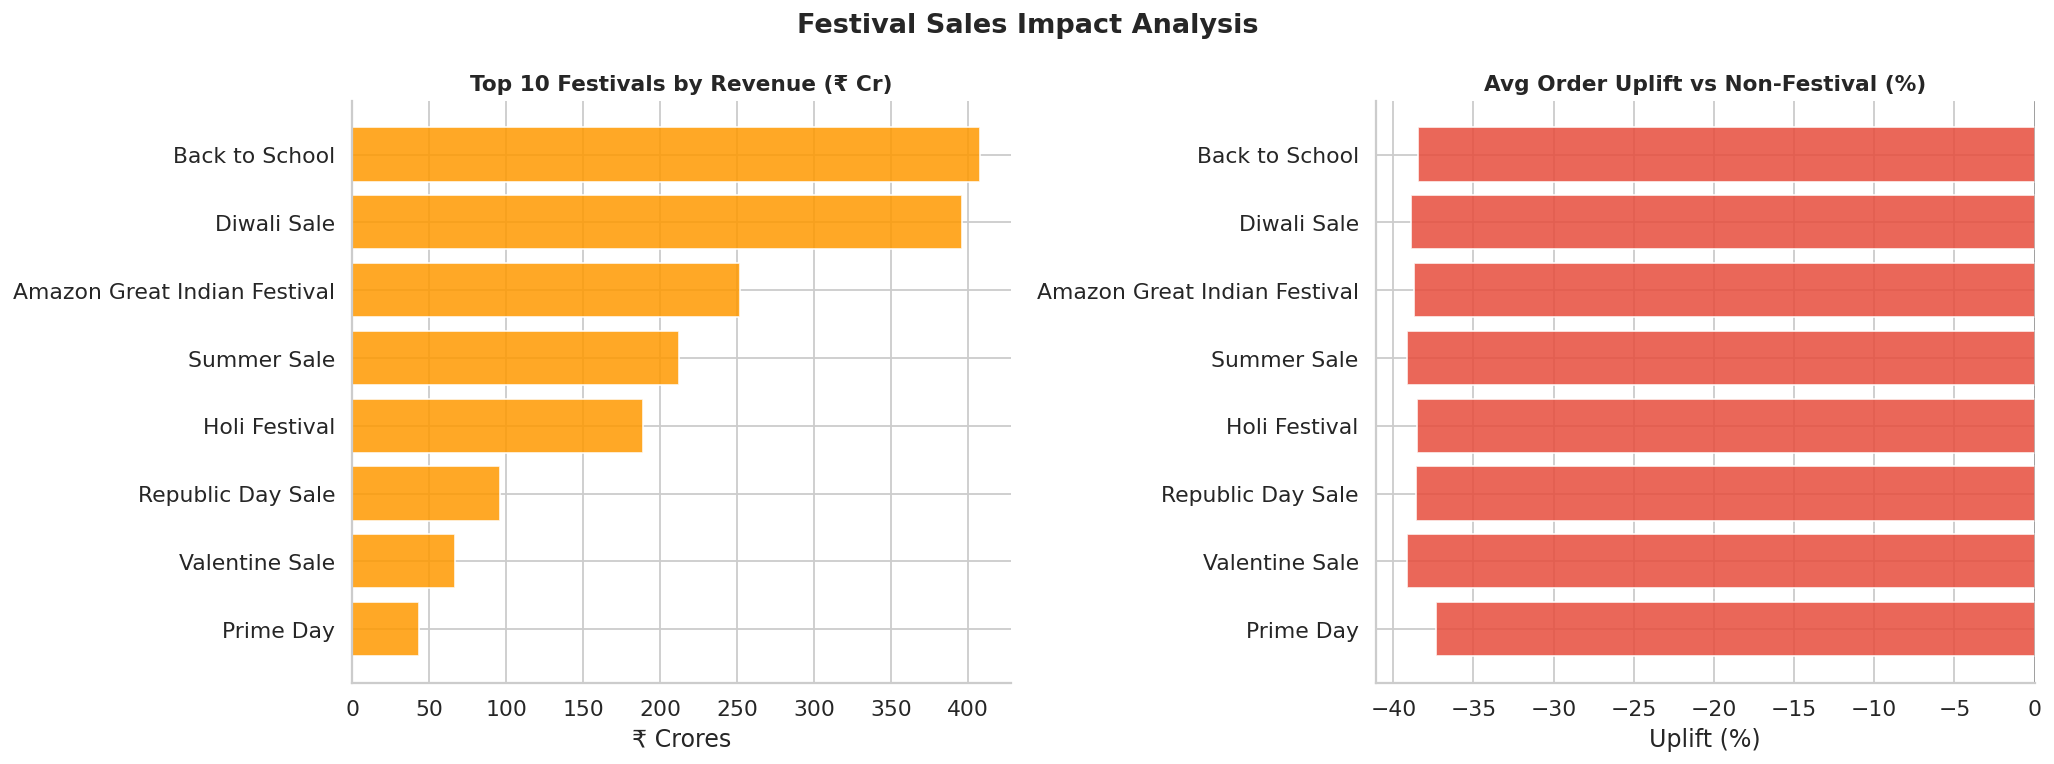


💡 INSIGHT:
   Non-festival avg order : ₹77,495
   Festival avg order     : ₹47,498
   Festival % of revenue  : 21.6%


In [14]:
fest = df[df['is_festival_sale'] == 1]
nonfest_avg = df[df['is_festival_sale'] == 0]['final_amount_inr'].mean()

fest_agg = (fest.groupby('festival_name')
               .agg(revenue=('final_amount_inr','sum'),
                    orders=('transaction_id','count'),
                    avg_order=('final_amount_inr','mean'))
               .reset_index()
               .sort_values('revenue', ascending=False))
fest_agg['rev_cr'] = fest_agg['revenue'] / 1e7
fest_agg['uplift'] = ((fest_agg['avg_order'] / nonfest_avg) - 1) * 100
top_fests = fest_agg.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_fests['festival_name'], top_fests['rev_cr'],
             color=ORANGE, alpha=0.85)
axes[0].set_title('Top 10 Festivals by Revenue (₹ Cr)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('₹ Crores')
axes[0].invert_yaxis()

uplift_colors = ['#2ECC71' if v >= 0 else '#E74C3C'
                 for v in top_fests['uplift']]
axes[1].barh(top_fests['festival_name'], top_fests['uplift'],
             color=uplift_colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Order Uplift vs Non-Festival (%)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Uplift (%)')
axes[1].invert_yaxis()

fig.suptitle('Festival Sales Impact Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('07_festival_impact.png')
plt.show()

print("\n💡 INSIGHT:")
print(f"   Non-festival avg order : ₹{nonfest_avg:,.0f}")
print(f"   Festival avg order     : ₹{fest['final_amount_inr'].mean():,.0f}")
total_fest_rev = fest['final_amount_inr'].sum() / df['final_amount_inr'].sum() * 100
print(f"   Festival % of revenue  : {total_fest_rev:.1f}%")

  💾 Saved → 08_age_behaviour.png


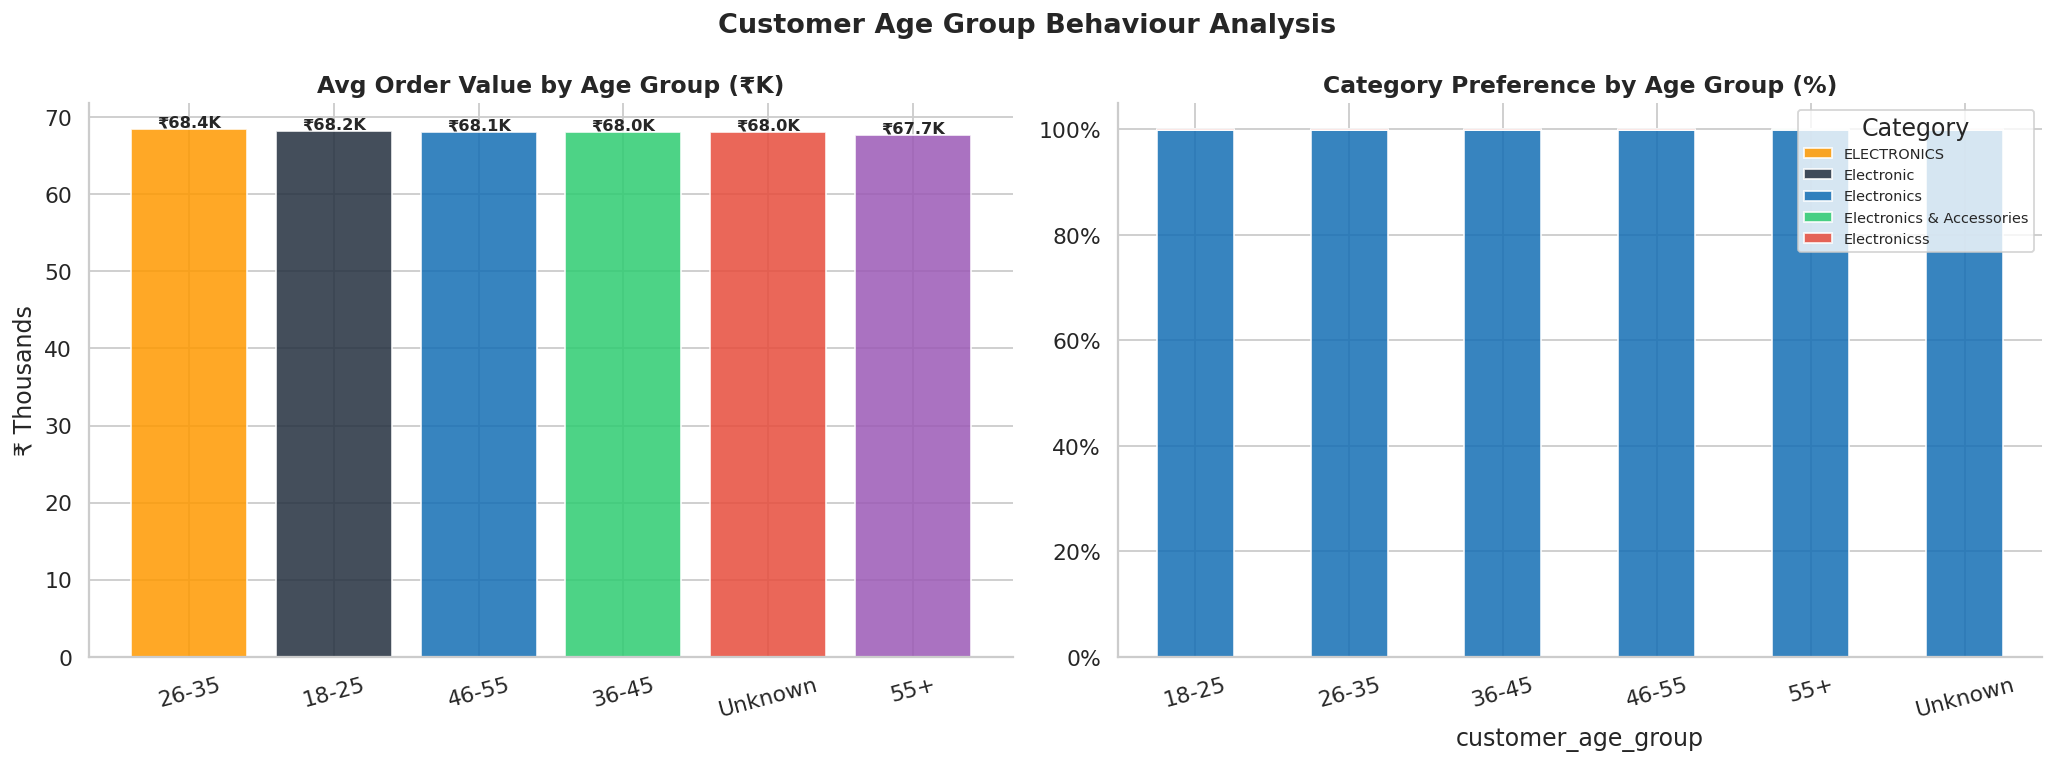


💡 INSIGHT:
   Highest AOV group : 26-35 — ₹68,391
   Lowest  AOV group : 55+ — ₹67,691


In [16]:
age_aov = (df.groupby('customer_age_group')['final_amount_inr']
             .mean()
             .sort_values(ascending=False))

age_cat = (df.groupby(['customer_age_group','category_x'])['final_amount_inr']
             .sum()
             .unstack(fill_value=0))
age_pct = age_cat.div(age_cat.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(age_aov.index, age_aov.values / 1000,
                   color=PALETTE[:len(age_aov)], alpha=0.85)
axes[0].set_title('Avg Order Value by Age Group (₹K)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('₹ Thousands')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'₹{bar.get_height():.1f}K',
                 ha='center', fontsize=9, fontweight='bold')

age_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=PALETTE[:len(age_pct.columns)], alpha=0.85)
axes[1].set_title('Category Preference by Age Group (%)',
                  fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(title='Category', fontsize=8, loc='upper right')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle('Customer Age Group Behaviour Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('08_age_behaviour.png')
plt.show()

print("\n💡 INSIGHT:")
print(f"   Highest AOV group : {age_aov.index[0]} — ₹{age_aov.iloc[0]:,.0f}")
print(f"   Lowest  AOV group : {age_aov.index[-1]} — ₹{age_aov.iloc[-1]:,.0f}")

  💾 Saved → 09_delivery_performance.png


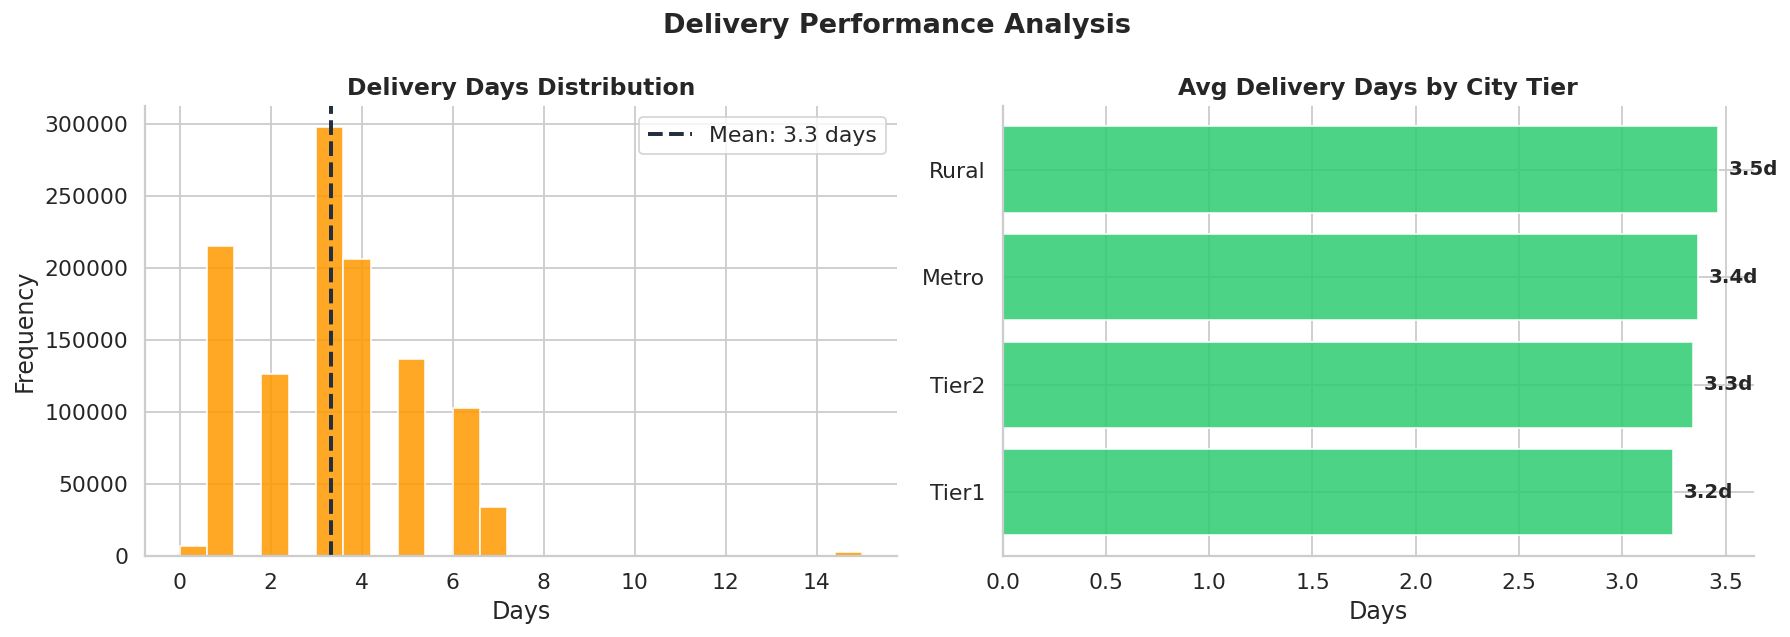


💡 INSIGHT:
   Fastest delivery: Tier1 — 3.2 days avg
   Slowest delivery: Rural — 3.5 days avg
   Gap              : 0.2 days


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution
axes[0].hist(df['delivery_days'].dropna(), bins=25,
             color=ORANGE, alpha=0.85, edgecolor='white')
mean_dd = df['delivery_days'].mean()
axes[0].axvline(mean_dd, color=DARK, linestyle='--',
                linewidth=2.2, label=f'Mean: {mean_dd:.1f} days')
axes[0].set_title('Delivery Days Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right: By tier
tier_del = (df.groupby('customer_tier')['delivery_days']
              .mean()
              .sort_values())
tier_colors_del = ['#2ECC71' if v < 4 else ORANGE if v < 6 else '#E74C3C'
                   for v in tier_del.values]
axes[1].barh(tier_del.index, tier_del.values,
             color=tier_colors_del, alpha=0.85)
axes[1].set_title('Avg Delivery Days by City Tier',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Days')
for i, (tier, val) in enumerate(tier_del.items()):
    axes[1].text(val + 0.05, i, f'{val:.1f}d',
                 va='center', fontsize=11, fontweight='bold')

fig.suptitle('Delivery Performance Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('09_delivery_performance.png')
plt.show()

print("\n💡 INSIGHT:")
fastest = tier_del.idxmin()
slowest = tier_del.idxmax()
print(f"   Fastest delivery: {fastest} — {tier_del.min():.1f} days avg")
print(f"   Slowest delivery: {slowest} — {tier_del.max():.1f} days avg")
print(f"   Gap              : {tier_del.max() - tier_del.min():.1f} days")

  💾 Saved → 10_return_analysis.png


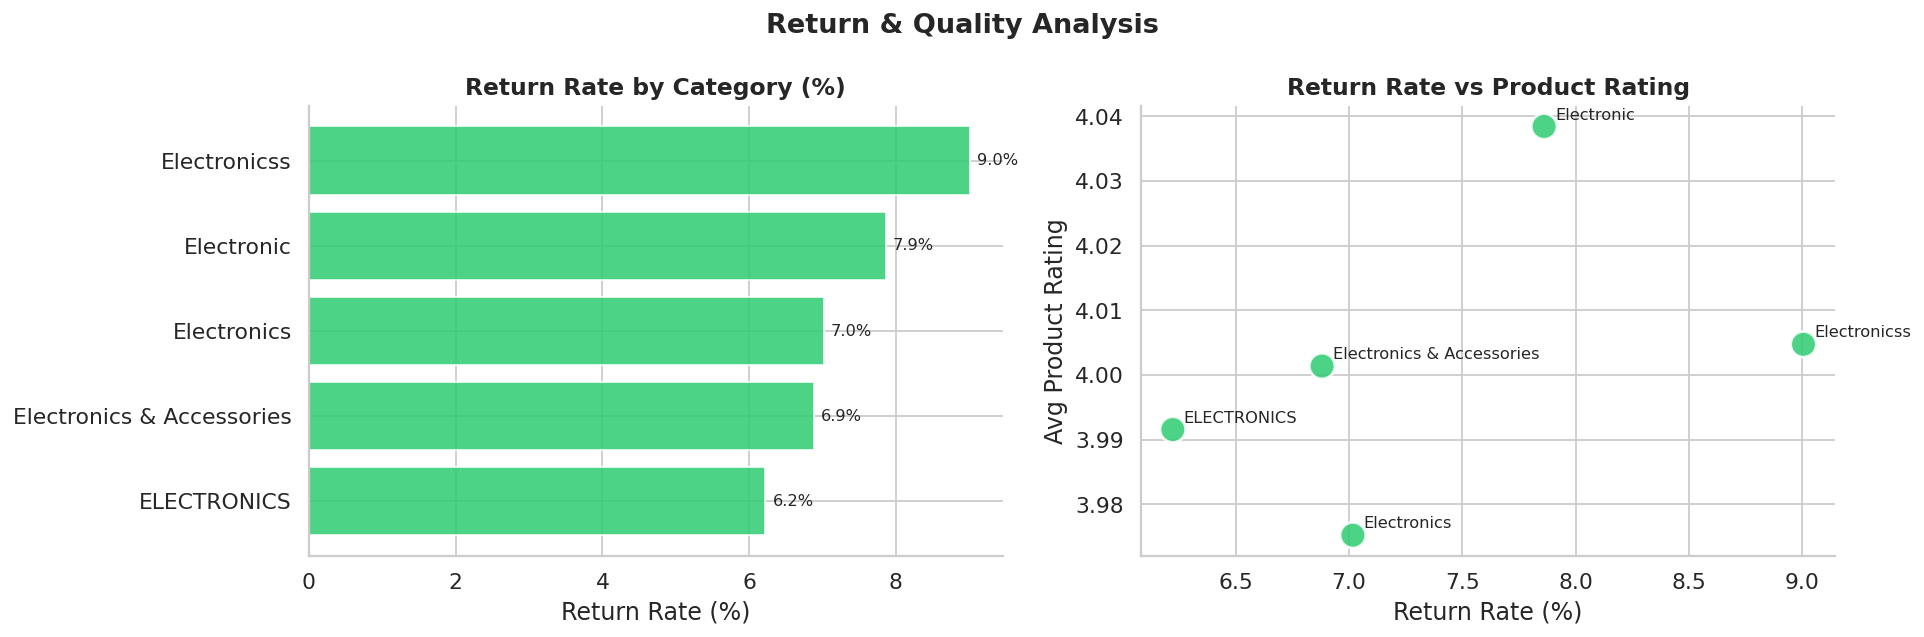


💡 INSIGHT:
   Highest return rate: Electronicss at 9.0%
   Overall return rate: 7.0%


In [18]:
if 'return_status' in df.columns:
    ret = (df.groupby('category_x')
             .apply(lambda x: pd.Series({
                 'total'      : len(x),
                 'returned'   : (x['return_status'] == 'Returned').sum(),
                 'return_rate': (x['return_status'] == 'Returned').mean() * 100,
                 'avg_rating' : x['product_rating'].mean()
             }))
             .reset_index()
             .sort_values('return_rate', ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    colors_ret = ['#E74C3C' if v > 15 else ORANGE if v > 10 else '#2ECC71'
                  for v in ret['return_rate']]
    axes[0].barh(ret['category_x'], ret['return_rate'],
                 color=colors_ret, alpha=0.85)
    axes[0].set_title('Return Rate by Category (%)',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Return Rate (%)')
    axes[0].invert_yaxis()
    for i, (_, row) in enumerate(ret.iterrows()):
        axes[0].text(row['return_rate'] + 0.1, i,
                     f"{row['return_rate']:.1f}%",
                     va='center', fontsize=9)

    axes[1].scatter(ret['return_rate'], ret['avg_rating'],
                    s=200, c=colors_ret, alpha=0.85,
                    edgecolors='white', linewidths=1.5)
    for _, row in ret.iterrows():
        axes[1].annotate(row['category_x'],
                         (row['return_rate'], row['avg_rating']),
                         textcoords='offset points',
                         xytext=(6, 4), fontsize=9)
    axes[1].set_title('Return Rate vs Product Rating',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Return Rate (%)')
    axes[1].set_ylabel('Avg Product Rating')

    fig.suptitle('Return & Quality Analysis',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_plot('10_return_analysis.png')
    plt.show()

    print("\n💡 INSIGHT:")
    print(f"   Highest return rate: {ret.iloc[0]['category_x']} at {ret.iloc[0]['return_rate']:.1f}%")
    print(f"   Overall return rate: {(df['return_status']=='Returned').mean()*100:.1f}%")

  💾 Saved → 11_discount_effectiveness.png


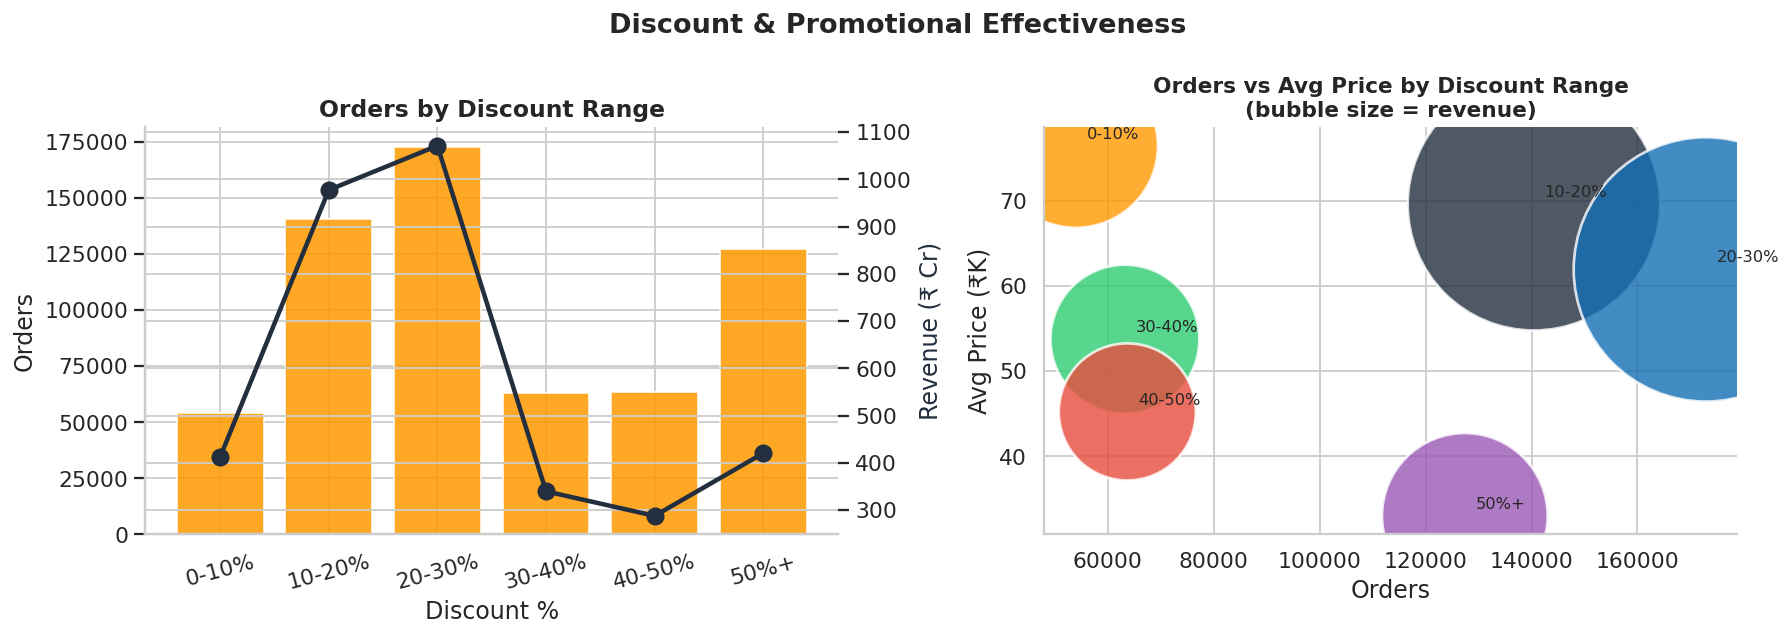


💡 INSIGHT: Sweet spot discount range = 20-30% (most orders)


In [19]:
if 'discount_percent' in df.columns:
    bins   = [0, 10, 20, 30, 40, 50, 100]
    labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','50%+']
    df['discount_band'] = pd.cut(df['discount_percent'],
                                 bins=bins, labels=labels)
    disc = (df.groupby('discount_band', observed=True)
              .agg(orders=('transaction_id','count'),
                   avg_price=('final_amount_inr','mean'),
                   total_rev=('final_amount_inr','sum'))
              .reset_index())
    disc['rev_cr'] = disc['total_rev'] / 1e7

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bars = axes[0].bar(disc['discount_band'].astype(str),
                       disc['orders'], color=ORANGE, alpha=0.85)
    axes[0].set_title('Orders by Discount Range', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Discount %'); axes[0].set_ylabel('Orders')
    axes[0].tick_params(axis='x', rotation=15)

    ax2 = axes[0].twinx()
    ax2.plot(disc['discount_band'].astype(str), disc['rev_cr'],
             'o-', color=DARK, linewidth=2.5, markersize=9)
    ax2.set_ylabel('Revenue (₹ Cr)', color=DARK)

    axes[1].scatter(disc['orders'], disc['avg_price']/1000,
                    s=disc['rev_cr']*20, c=PALETTE[:len(disc)],
                    alpha=0.8, edgecolors='white', linewidths=1.5)
    for _, row in disc.iterrows():
        axes[1].annotate(str(row['discount_band']),
                         (row['orders'], row['avg_price']/1000),
                         textcoords='offset points',
                         xytext=(6, 4), fontsize=9)
    axes[1].set_title('Orders vs Avg Price by Discount Range\n(bubble size = revenue)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Orders'); axes[1].set_ylabel('Avg Price (₹K)')

    fig.suptitle('Discount & Promotional Effectiveness',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_plot('11_discount_effectiveness.png')
    plt.show()

    sweet = disc.loc[disc['orders'].idxmax(), 'discount_band']
    print(f"\n💡 INSIGHT: Sweet spot discount range = {sweet} (most orders)")

  💾 Saved → 12_brand_performance.png


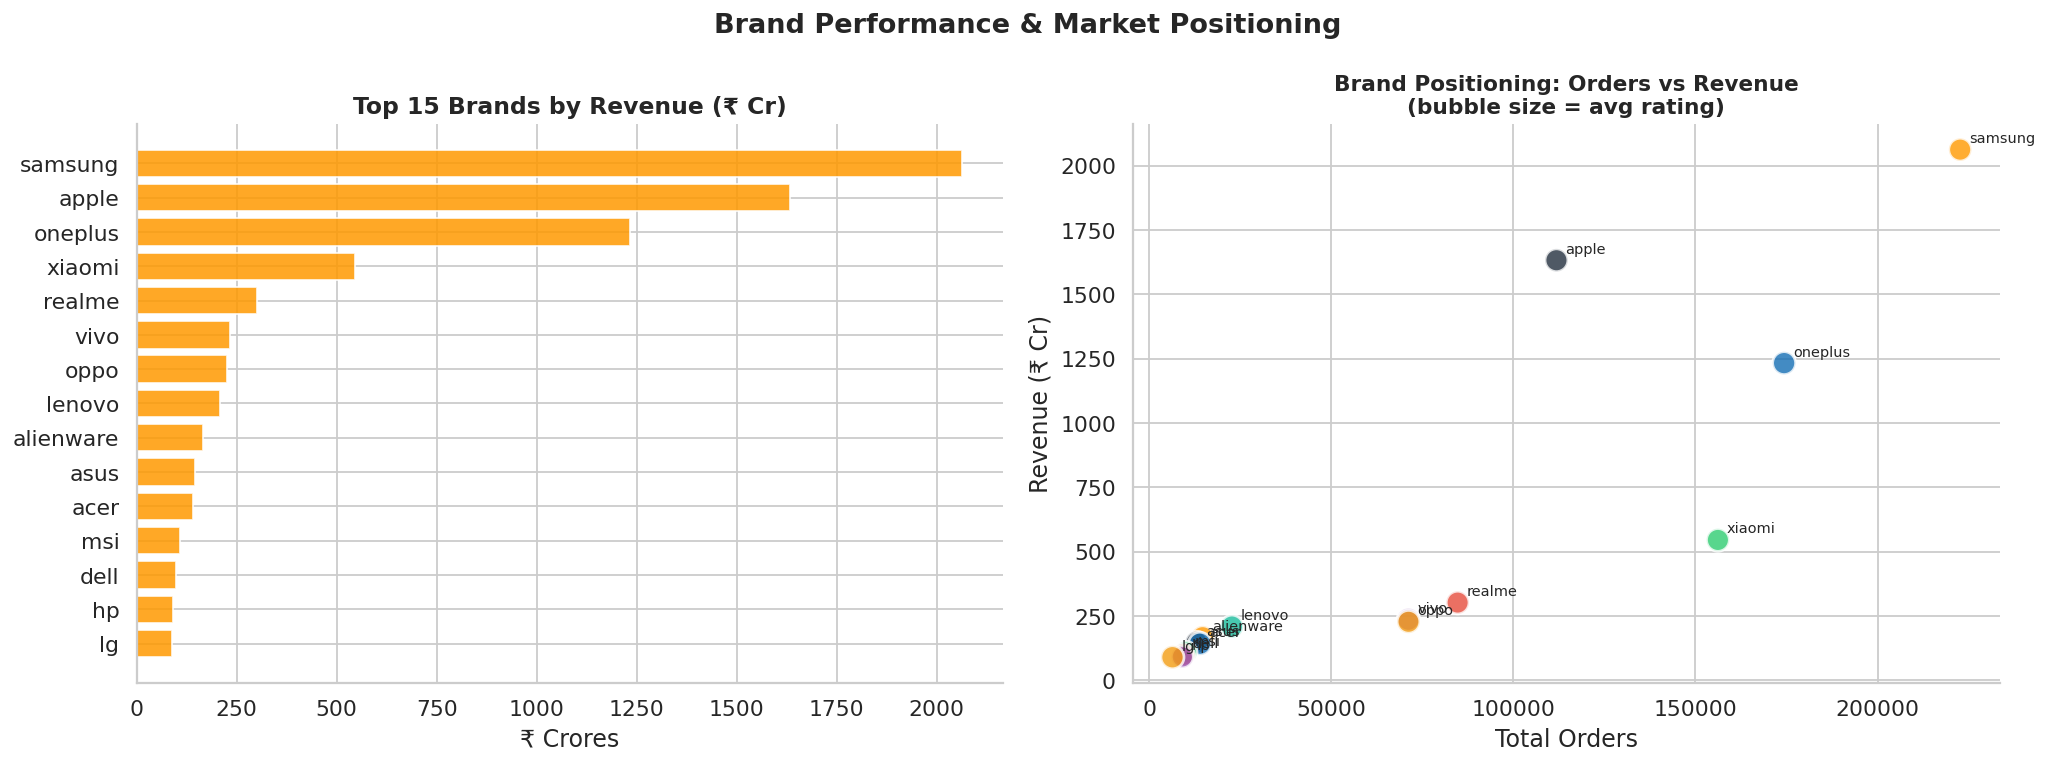

In [24]:
brand = (df.groupby('brand_y')
           .agg(revenue=('final_amount_inr','sum'),
                orders=('transaction_id','count'),
                avg_rating=('product_rating','mean'))
           .reset_index()
           .sort_values('revenue', ascending=False))

brand['rev_cr'] = brand['revenue'] / 1e7
top15 = brand.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Top 15 Brands by Revenue
axes[0].barh(top15['brand_y'], top15['rev_cr'],
             color=ORANGE, alpha=0.85)
axes[0].set_title('Top 15 Brands by Revenue (₹ Cr)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('₹ Crores')
axes[0].invert_yaxis()

# Right: Brand Positioning (Orders vs Revenue)
# Fix color length: repeat PALETTE and slice to match top15
colors = (PALETTE * ((len(top15) // len(PALETTE)) + 1))[:len(top15)]

sc = axes[1].scatter(top15['orders'], top15['rev_cr'],
                     s=top15['avg_rating'] * 40,
                     c=colors, alpha=0.8,
                     edgecolors='white', linewidths=1.5)

for _, row in top15.iterrows():
    axes[1].annotate(row['brand_y'],
                     (row['orders'], row['rev_cr']),
                     textcoords='offset points',
                     xytext=(5, 4), fontsize=8)

axes[1].set_title('Brand Positioning: Orders vs Revenue\n(bubble size = avg rating)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Revenue (₹ Cr)')

fig.suptitle('Brand Performance & Market Positioning',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('12_brand_performance.png')
plt.show()

  💾 Saved → 13_rfm_segmentation.png


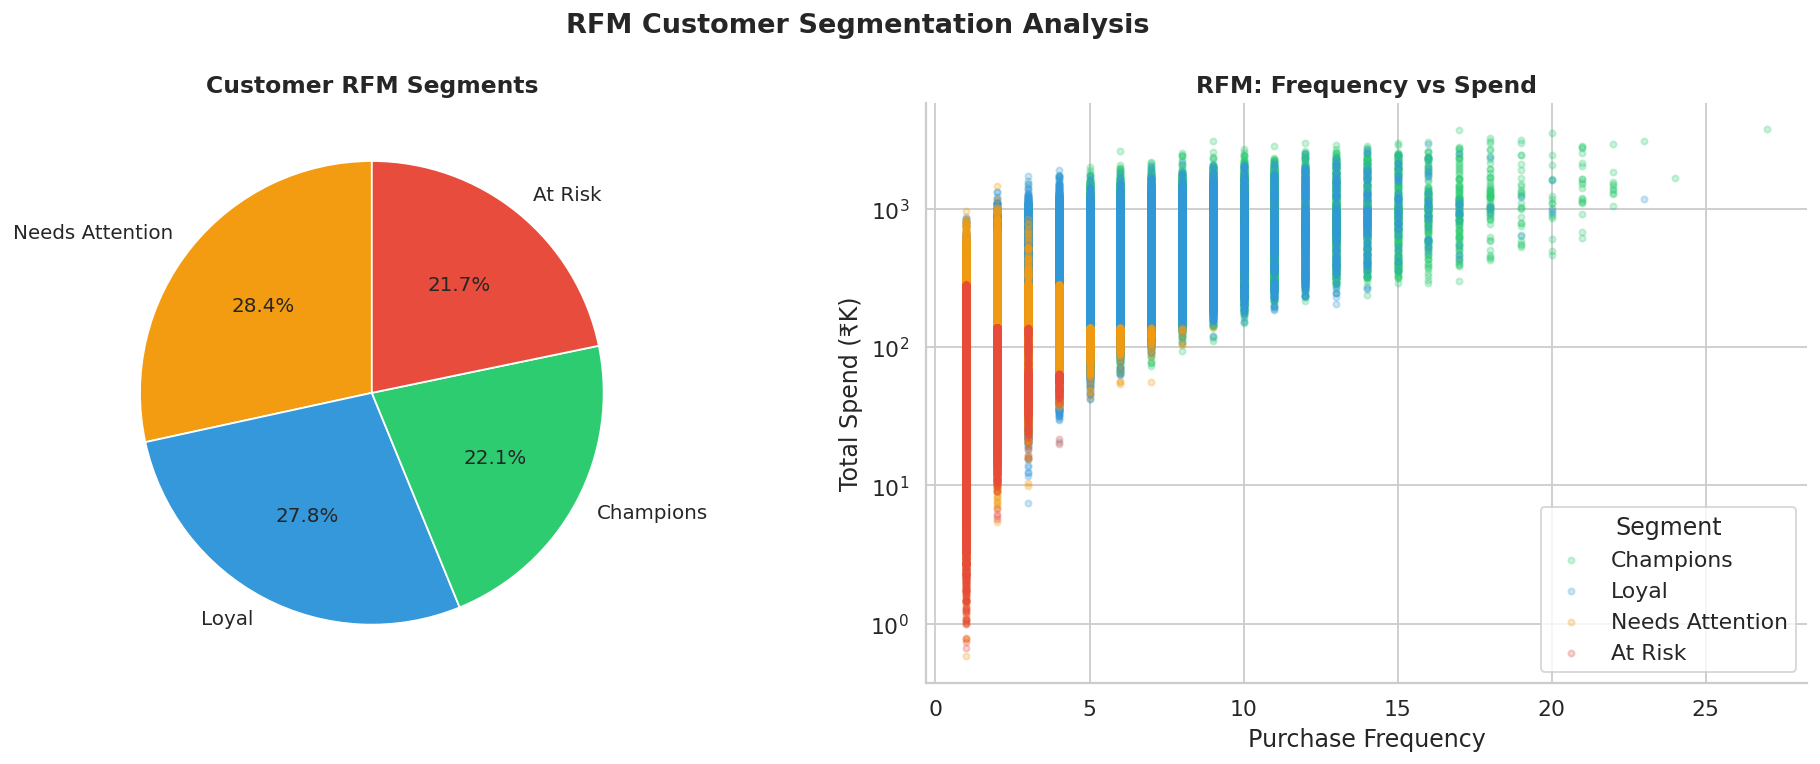


💡 INSIGHT:
   Needs Attention     : 100,853 customers (28.4%)
   Loyal               : 98,590 customers (27.8%)
   Champions           : 78,344 customers (22.1%)
   At Risk             : 77,182 customers (21.7%)


In [25]:
max_date = df['order_date'].max()
rfm = (df.groupby('customer_id')
         .agg(recency  = ('order_date', lambda x: (max_date - x.max()).days),
              frequency= ('transaction_id', 'count'),
              monetary = ('final_amount_inr', 'sum'))
         .reset_index())

# Score each dimension 1–4
for col, rev in [('recency', True), ('frequency', False), ('monetary', False)]:
    try:
        labels = [4,3,2,1] if rev else [1,2,3,4]
        rfm[f'{col[0].upper()}_score'] = pd.qcut(
            rfm[col], 4, labels=labels, duplicates='drop')
    except Exception:
        rfm[f'{col[0].upper()}_score'] = pd.cut(
            rfm[col].rank(method='first'), 4, labels=[1,2,3,4])

rfm['RFM_total'] = (rfm['R_score'].astype(float) +
                    rfm['F_score'].astype(float) +
                    rfm['M_score'].astype(float))

rfm['segment'] = pd.cut(rfm['RFM_total'], bins=4,
                         labels=['At Risk','Needs Attention','Loyal','Champions'])

SEG_COLORS = {'Champions':'#2ECC71','Loyal':'#3498DB',
              'Needs Attention':'#F39C12','At Risk':'#E74C3C'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

seg_counts = rfm['segment'].value_counts()
axes[0].pie(seg_counts,
            labels=seg_counts.index,
            autopct='%1.1f%%',
            colors=[SEG_COLORS.get(s,'grey') for s in seg_counts.index],
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Customer RFM Segments', fontsize=13, fontweight='bold')

for seg, color in SEG_COLORS.items():
    mask = rfm['segment'] == seg
    axes[1].scatter(rfm.loc[mask,'frequency'],
                    rfm.loc[mask,'monetary'] / 1000,
                    alpha=0.25, s=12, color=color, label=seg)
axes[1].set_xlabel('Purchase Frequency')
axes[1].set_ylabel('Total Spend (₹K)')
axes[1].set_title('RFM: Frequency vs Spend', fontsize=13, fontweight='bold')
axes[1].legend(title='Segment')
axes[1].set_yscale('log')

fig.suptitle('RFM Customer Segmentation Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('13_rfm_segmentation.png')
plt.show()

print("\n💡 INSIGHT:")
for seg, cnt in seg_counts.items():
    print(f"   {seg:<20}: {cnt:,} customers ({cnt/len(rfm)*100:.1f}%)")

  💾 Saved → 14_cohort_analysis.png


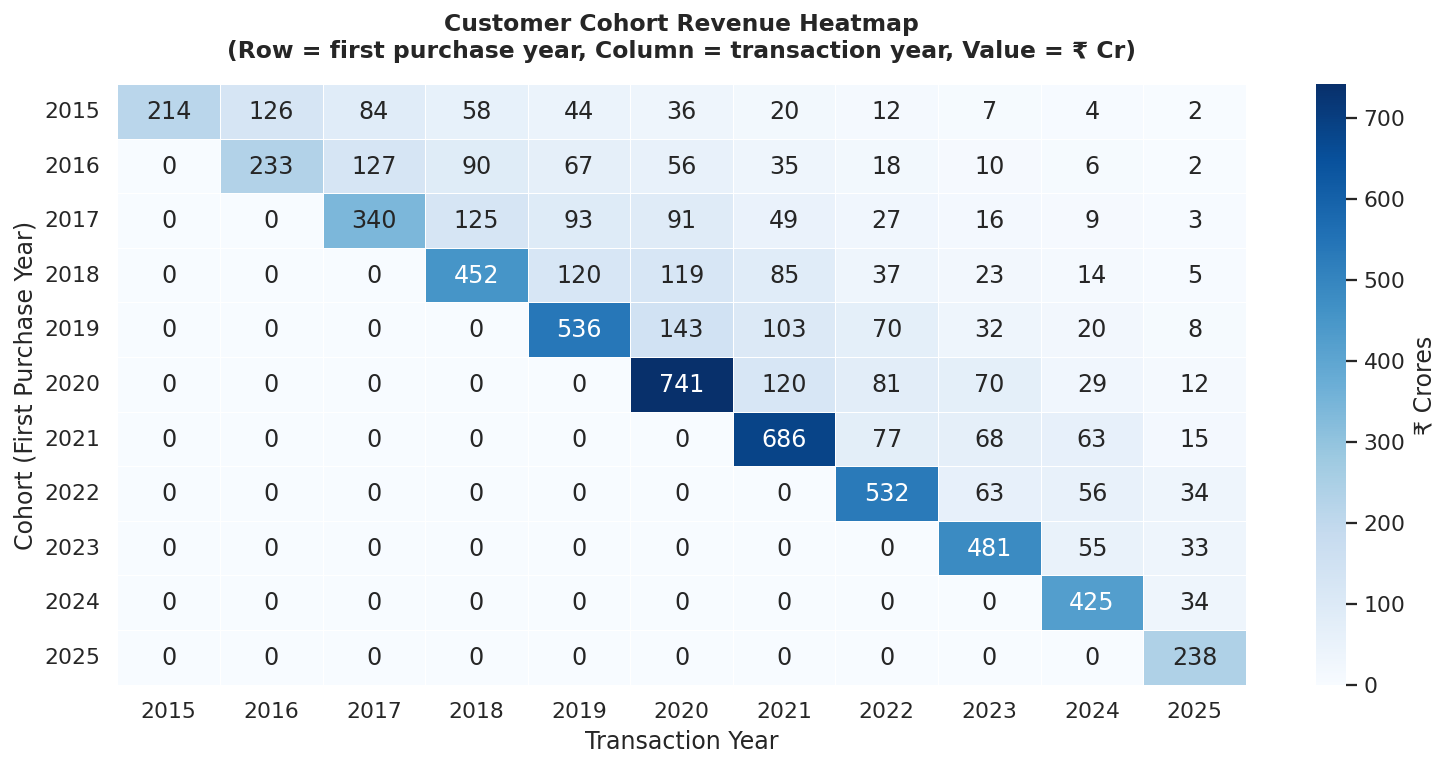


💡 INSIGHT:
   Highest lifetime value cohort: 2020
   Their total revenue: ₹1053Cr


In [26]:
df['cohort_year'] = df.groupby('customer_id')['order_year'].transform('min')
cohort_tbl = (df.groupby(['cohort_year','order_year'])['final_amount_inr']
                .sum()
                .unstack(fill_value=0) / 1e7)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cohort_tbl, annot=True, fmt='.0f',
            cmap='Blues', ax=ax, linewidths=0.5,
            cbar_kws={'label': '₹ Crores'})
ax.set_title('Customer Cohort Revenue Heatmap\n(Row = first purchase year, Column = transaction year, Value = ₹ Cr)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Transaction Year')
ax.set_ylabel('Cohort (First Purchase Year)')
save_plot('14_cohort_analysis.png')
plt.show()

print("\n💡 INSIGHT:")
best_cohort = cohort_tbl.sum(axis=1).idxmax()
print(f"   Highest lifetime value cohort: {best_cohort}")
print(f"   Their total revenue: ₹{cohort_tbl.sum(axis=1).max():.0f}Cr")

  💾 Saved → 15_spending_tiers.png


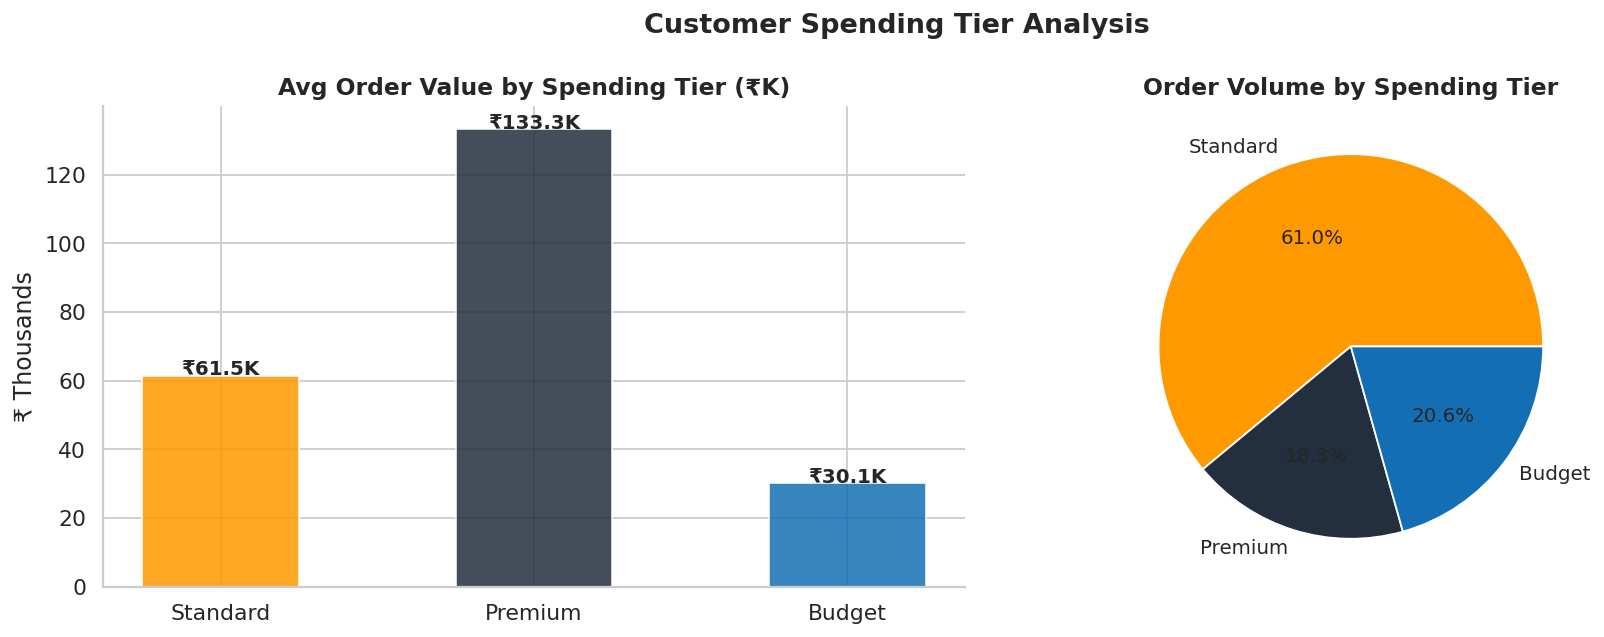

In [27]:
spend = (df.groupby('customer_spending_tier')
           .agg(orders  = ('transaction_id','count'),
                revenue = ('final_amount_inr','sum'),
                avg_val = ('final_amount_inr','mean'))
           .reset_index()
           .sort_values('revenue', ascending=False))
spend['rev_cr'] = spend['revenue'] / 1e7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(spend['customer_spending_tier'], spend['avg_val'] / 1000,
                   color=PALETTE[:len(spend)], alpha=0.85, width=0.5)
axes[0].set_title('Avg Order Value by Spending Tier (₹K)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('₹ Thousands')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'₹{bar.get_height():.1f}K',
                 ha='center', fontweight='bold', fontsize=11)

axes[1].pie(spend['orders'],
            labels=spend['customer_spending_tier'],
            autopct='%1.1f%%',
            colors=PALETTE[:len(spend)],
            textprops={'fontsize': 11})
axes[1].set_title('Order Volume by Spending Tier',
                  fontsize=13, fontweight='bold')

fig.suptitle('Customer Spending Tier Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_plot('15_spending_tiers.png')
plt.show()

In [29]:
print("=" * 65)
print("EDA COMPLETE — KEY BUSINESS INSIGHTS")
print("=" * 65)

total_rev = df['final_amount_inr'].sum() / 1e7
print(f"""
📊 DATASET
   Total transactions : {len(df):,}
   Date range         : {df['order_date'].min().date()} → {df['order_date'].max().date()}
   Total revenue      : ₹{total_rev:,.0f} Crores
   Unique customers   : {df['customer_id'].nunique():,}

💰 REVENUE
   Avg order value    : ₹{df['final_amount_inr'].mean():,.0f}
   Top category       : {df.groupby('category_x')['final_amount_inr'].sum().idxmax()}
   Top city           : {df.groupby('customer_city')['final_amount_inr'].sum().idxmax()}

⭐ CUSTOMERS
   Prime member %     : {df['is_prime_member'].mean()*100:.1f}%
   Avg product rating : {df['product_rating'].mean():.2f}/5.0
   Avg delivery days  : {df['delivery_days'].mean():.1f} days

💳 PAYMENTS
   Unique methods     : {df['payment_method'].nunique()}
   Most popular       : {df['payment_method'].value_counts().index[0]}

🎆 FESTIVALS
   Festival orders    : {df['is_festival_sale'].mean()*100:.1f}% of total
   Festival avg order : ₹{df[df['is_festival_sale']==1]['final_amount_inr'].mean():,.0f}
   Non-fest avg order : ₹{df[df['is_festival_sale']==0]['final_amount_inr'].mean():,.0f}
""")
print("=" * 65)
print("✅ All charts saved to screenshots/eda/ folder")
print("\nNext step → Phase 3: Power BI Dashboard")
print("=" * 65)

EDA COMPLETE — KEY BUSINESS INSIGHTS

📊 DATASET
   Total transactions : 1,127,609
   Date range         : 2015-01-01 → 2025-12-31
   Total revenue      : ₹7,689 Crores
   Unique customers   : 354,969

💰 REVENUE
   Avg order value    : ₹68,187
   Top category       : Electronics
   Top city           : Mumbai

⭐ CUSTOMERS
   Prime member %     : 38.1%
   Avg product rating : 3.98/5.0
   Avg delivery days  : 3.3 days

💳 PAYMENTS
   Unique methods     : 7
   Most popular       : UPI

🎆 FESTIVALS
   Festival orders    : 31.0% of total
   Festival avg order : ₹47,498
   Non-fest avg order : ₹77,495

✅ All charts saved to screenshots/eda/ folder

Next step → Phase 3: Power BI Dashboard
